# 03. Entrenamiento del modelo

Objetivo de este notebook:Utilizar el dataset estratificado para entrenar un modelo predictivo capaz de aprender la frontera matemática entre una clasificación satelital correcta y una transición espuria.

Emplearemos un RandomForestClassifier. Para que el modelo tenga contexto, le entregaremos tres variables explicativas (nuestras variables independientes o $X$):El clima (Temperatura y Precipitación), y el tipo de cobertura original en 2019 (porque no es lo mismo una sequía sobre un bosque profundo que sobre un pastizal).Nuestra variable a predecir (Target o $y$) será es_espurio. Finalmente, evaluaremos qué tan inteligente se volvió el algoritmo midiendo su precisión.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


Dividiremos nuestros 2.000 puntos: el 80% servirá para entrenar al modelo, y  el 20% restante para evaluarlo al final.

In [2]:
# 1. Cargar el dataset que creamos en el Notebook 2
ruta_datos = 'data/dataset_etiquetado.csv'
df = pd.DataFrame(pd.read_csv(ruta_datos))

# 2. Definir nuestras Variables Explicativas (X) y lo que queremos predecir (y)
X = df[['classification_2019', 'temperature_2m', 'total_precipitation_sum']]
y = df['es_espurio']

# 3. Dividir los datos (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Datos listos. Entrenaremos con {len(X_train)} ejemplos y evaluaremos con {len(X_test)} ejemplos.")

Datos listos. Entrenaremos con 1600 ejemplos y evaluaremos con 400 ejemplos.


Instanciamos nuestro Bosque Aleatorio con 100 árboles de decisión matemáticos. Al ejecutar la función .fit(), el algoritmo procesa todas las filas y encuentra los patrones climáticos que generan el error del satélite.

In [3]:
# Crear el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# Pedirle que intente predecir el 20% de datos de testeo
predicciones = modelo_rf.predict(X_test)



## Evaluación de resultados 

Generaremos una "Matriz de Confusión" para ver cuántos aciertos y errores tuvo nuestro modelo. Además, le preguntaremos al algoritmo cuál de las tres variables fue la más importante para darse cuenta de que el satélite se había equivocado.

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

  Normal (0)       0.78      0.80      0.79       200
 Espurio (1)       0.80      0.78      0.79       200

    accuracy                           0.79       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.79      0.79      0.79       400



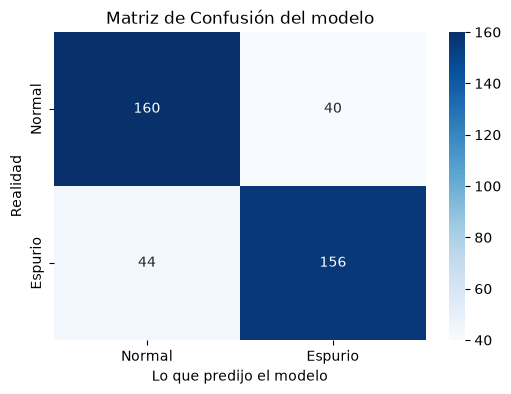

C:\Users\Fernanda\AppData\Local\Temp\ipykernel_4512\1549020210.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=nombres_variables, palette='viridis')


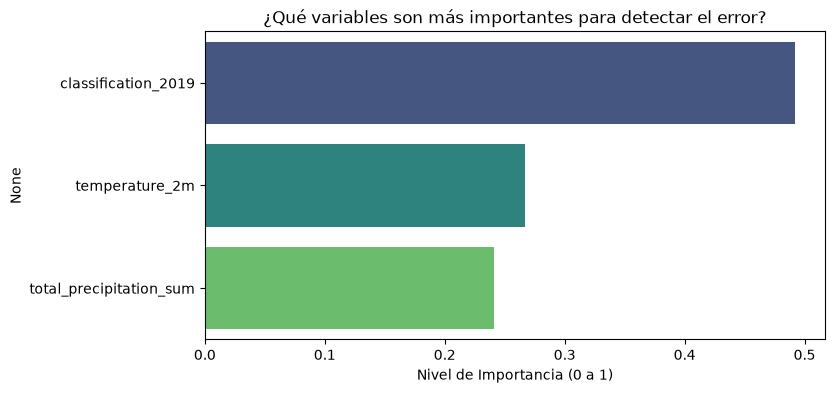

In [ ]:
# 1. Reporte de Métricas
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones, target_names=['Normal (0)', 'Espurio (1)']))

# 2. Graficar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predicciones), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Espurio'], yticklabels=['Normal', 'Espurio'])
plt.title("Matriz de Confusión del modelo")
plt.ylabel("Realidad")
plt.xlabel("Lo que predijo el modelo")
plt.show()

# 3. Graficar la "Importancia de las Variables" (Feature Importance)
importancias = modelo_rf.feature_importances_
nombres_variables = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importancias, y=nombres_variables, palette='viridis')
plt.title("¿Qué variables son más importantes para detectar el error?")
plt.xlabel("Nivel de Importancia (0 a 1)")
plt.show()